<a href="https://colab.research.google.com/github/sajidruetcse21/Language-Invariant-Emotion-Detection-Using-Contrastive-Learning/blob/main/Base_Model(Bengali_to_Bengali%2C_with_class_imbalance).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# CELL 1
# Install required libraries for training and evaluation
# ==========================================================

!pip install transformers scikit-learn pandas openpyxl seaborn

In [ ]:
# ==========================================================
# CELL 2
# Import all required Python libraries
# ==========================================================

import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW  # Corrected import for AdamW

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# ==========================================================
# CELL 3
# Check whether GPU is available
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ==========================================================
# CELL 4
# Load dataset splits from CSV files
# ==========================================================

train_df = pd.read_csv("/content/train.csv")
val_df = pd.read_csv("/content/validation.csv")
test_df = pd.read_csv("/content/test.csv")

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

train_df.head()

Train size: 56067
Validation size: 7929
Test size: 16101


,Label,Bengali,Banglish,English
0,anger,মিন্নী যে জঘন্য কাজ করার পরও যদি জামিন পায়।তাহ...,minni je joghonjo kaj korar poro jodi jamin pa...,"If Minni gets bail despite the heinous act, th..."
1,joy,আলহামদুলিল্লাহ অবশেষে এখান থেকে বেরিয়ে এসে পা...,alhamdulillah obosheshe ekhan theke beriye esh...,Alhamdulillah he is finally able to get out of...
2,disgust,আপনার উচিত ছিল ওদের দিয়ে গাড়ি ঠিক করানো এরপর...,apnar ucit chil oder diye gari thik korano ero...,"You should have fixed the car with them, then ..."
3,disgust,মিন্নী কে মুক্তি দেওয়া হউক &#39; তার কারণ এই খ...,minni ke mukti deoya huk &#39; tar karon ei kh...,Let Minni be released &#39; The reason is that...
4,sadness,গানটা শুনলে কোনো 😢এক অচেনা শহরে হারিয়ে যায়😢 হয়...,ganta shunle kono 😢ek ocena shohore hariye jay...,Listening to the song makes one 😢 get lost in ...


In [ ]:
# ==========================================================
# CELL 5
# Select which language column will be used for training
# and which will be used for testing
# ==========================================================

TRAIN_TEXT_COLUMN = "Bengali"
TEST_TEXT_COLUMN = "Bengali"

LABEL_COLUMN = "Label"

In [ ]:
# ==========================================================
# CELL 6
# Convert emotion labels into numerical form
# ==========================================================

label_encoder = LabelEncoder()

train_df[LABEL_COLUMN] = label_encoder.fit_transform(train_df[LABEL_COLUMN])
val_df[LABEL_COLUMN] = label_encoder.transform(val_df[LABEL_COLUMN])
test_df[LABEL_COLUMN] = label_encoder.transform(test_df[LABEL_COLUMN])

num_labels = len(label_encoder.classes_)
print("Number of emotion classes:", num_labels)
print("Classes:", label_encoder.classes_)

Number of emotion classes: 6
Classes: ['anger' 'disgust' 'fear' 'joy' 'sadness' 'surprise']


In [ ]:
# ==========================================================
# CELL 7
# Load tokenizer for multilingual transformer
# ==========================================================

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# ==========================================================
# CELL 8
# Custom Dataset class for tokenizing text and loading labels
# ==========================================================

class EmotionDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        item = {key: val.squeeze() for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx])

        return item

In [ ]:
# ==========================================================
# CELL 9
# Create dataset objects for train, validation, and test
# ==========================================================

train_dataset = EmotionDataset(
    train_df[TRAIN_TEXT_COLUMN].tolist(),
    train_df[LABEL_COLUMN].tolist()
)

val_dataset = EmotionDataset(
    val_df[TRAIN_TEXT_COLUMN].tolist(),
    val_df[LABEL_COLUMN].tolist()
)

test_dataset = EmotionDataset(
    test_df[TEST_TEXT_COLUMN].tolist(),
    test_df[LABEL_COLUMN].tolist()
)

In [ ]:
# ==========================================================
# CELL 9 (MODIFIED FOR MULTILINGUAL TRAINING)
# Create datasets using Bangla + Banglish + English together
# ==========================================================

# # ----- TRAIN SET -----

# train_texts = (
#     train_df["Bengali"].tolist() +
#     train_df["Banglish"].tolist() +
#     train_df["English"].tolist()
# )

# train_labels = (
#     train_df[LABEL_COLUMN].tolist() +
#     train_df[LABEL_COLUMN].tolist() +
#     train_df[LABEL_COLUMN].tolist()
# )

# train_dataset = EmotionDataset(train_texts, train_labels)


# # ----- VALIDATION SET -----

# val_texts = (
#     val_df["Bengali"].tolist() +
#     val_df["Banglish"].tolist() +
#     val_df["English"].tolist()
# )

# val_labels = (
#     val_df[LABEL_COLUMN].tolist() +
#     val_df[LABEL_COLUMN].tolist() +
#     val_df[LABEL_COLUMN].tolist()
# )

# val_dataset = EmotionDataset(val_texts, val_labels)


# # ----- TEST SET -----

# test_texts = (
#     test_df["Bengali"].tolist() +
#     test_df["Banglish"].tolist() +
#     test_df["English"].tolist()
# )

# test_labels = (
#     test_df[LABEL_COLUMN].tolist() +
#     test_df[LABEL_COLUMN].tolist() +
#     test_df[LABEL_COLUMN].tolist()
# )

# test_dataset = EmotionDataset(test_texts, test_labels)

In [ ]:
# ==========================================================
# CELL 10
# Create DataLoaders for batching during training
# ==========================================================

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
# ==========================================================
# CELL 11
# Load multilingual transformer model for classification
# ==========================================================

model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=num_labels
)

model.to(device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=6, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [ ]:
# ==========================================================
# CELL 12
# Initialize AdamW optimizer
# ==========================================================

optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
# ==========================================================
# CELL 13
# Function to train the model for one epoch
# ==========================================================
from tqdm.auto import tqdm

def train_epoch(epoch_num):

    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch_num}")

    for batch_idx, batch in enumerate(progress_bar):

        batch = {k:v.to(device) for k,v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # Update progress bar with current batch loss
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(train_loader)

In [ ]:
# ==========================================================
# CELL 14
# Evaluate model performance using accuracy and macro F1
# ==========================================================

def evaluate(loader):

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            batch = {k:v.to(device) for k,v in batch.items()}

            outputs = model(**batch)

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(labels, preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro"
    )

    return acc, precision, recall, f1

In [ ]:
# ==========================================================
# CELL 15
# Training loop for multiple epochs
# ==========================================================

EPOCHS = 5

for epoch in range(EPOCHS):

    train_loss = train_epoch(epoch + 1) # Pass epoch + 1 to the function

    val_acc, val_p, val_r, val_f1 = evaluate(val_loader)

    print(f"\nEpoch {epoch+1}") # Added a newline for better readability
    print("Train Loss:", train_loss)
    print("Validation Accuracy:", val_acc)
    print("Validation Macro F1:", val_f1)

Training Epoch 1:   0%|          | 0/3505 [00:00<?, ?it/s]


Epoch 1
Train Loss: 1.0982218816600071
Validation Accuracy: 0.5974271660991298
Validation Macro F1: 0.5898008016895729


Training Epoch 2:   0%|          | 0/3505 [00:00<?, ?it/s]


Epoch 2
Train Loss: 0.9320371307932191
Validation Accuracy: 0.6448480262328162
Validation Macro F1: 0.6448833688692294


Training Epoch 3:   0%|          | 0/3505 [00:00<?, ?it/s]


Epoch 3
Train Loss: 0.8230690516860951
Validation Accuracy: 0.6421995207466263
Validation Macro F1: 0.6371075024869227


Training Epoch 4:   0%|          | 0/3505 [00:00<?, ?it/s]


Epoch 4
Train Loss: 0.7158065306732215
Validation Accuracy: 0.6467398158658091
Validation Macro F1: 0.6461416109510526


Training Epoch 5:   0%|          | 0/3505 [00:00<?, ?it/s]


Epoch 5
Train Loss: 0.6148796261504781
Validation Accuracy: 0.6530457813091184
Validation Macro F1: 0.6512521992995471


In [ ]:
# ==========================================================
# CELL 16
# Evaluate model on the test dataset
# ==========================================================

test_acc, test_p, test_r, test_f1 = evaluate(test_loader)

print("TEST RESULTS")
print("Accuracy:", test_acc)
print("Precision:", test_p)
print("Recall:", test_r)
print("Macro F1:", test_f1)

TEST RESULTS
Accuracy: 0.6522576237500777
Precision: 0.6729021337385919
Recall: 0.641744653251963
Macro F1: 0.6503324432213969


In [ ]:
# ==========================================================
# CELL 17
# Generate and display confusion matrix for test predictions
# ==========================================================

def plot_confusion_matrix(loader):

    model.eval()

    pred_labels = []
    true_labels = []

    with torch.no_grad():

        for batch in loader:

            batch = {k:v.to(device) for k,v in batch.items()}

            outputs = model(**batch)

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            pred_labels.extend(predictions.cpu().numpy())
            true_labels.extend(batch["labels"].cpu().numpy())

    cm = confusion_matrix(true_labels, pred_labels)

    class_names = label_encoder.classes_

    plt.figure(figsize=(10,8)) # Increased figure size for better resolution

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues", # Added cmap for better visualization
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    # Save high resolution image
    plt.savefig("confusion_matrix.png", dpi=600, bbox_inches="tight")
    plt.show()

    print("Confusion matrix saved as confusion_matrix.png")

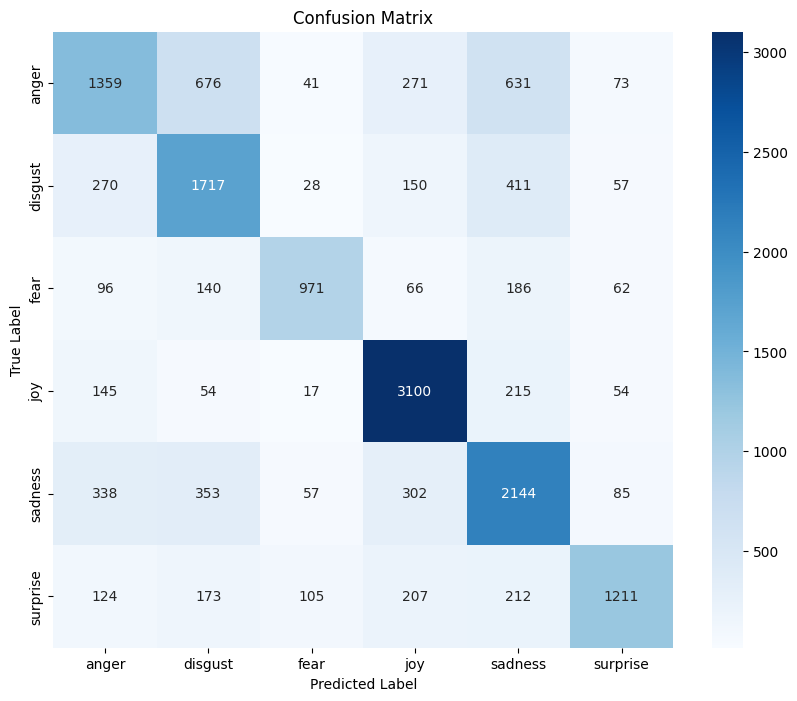

Confusion matrix saved as confusion_matrix.png


In [ ]:
# ==========================================================
# CELL 18
# Call function to visualize confusion matrix
# ==========================================================

plot_confusion_matrix(test_loader)